# ConvNeXt-Tiny Capacity Hyperparameter Re-Sweep (`d_model`, `dropout`)

In [1]:
import csv
import random
import re
import json
import time
import math
import copy
import traceback
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.checkpoint import checkpoint
from sklearn.metrics import (f1_score, roc_auc_score, mean_absolute_error, mean_squared_error,
                              accuracy_score, recall_score, r2_score, confusion_matrix, roc_curve)
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

MANIFEST = Path('~/Desktop/convscript/Code/Manifest/manifests/master_manifest.csv').expanduser()
ROOT     = Path('~/Desktop/Thesis/TR-6').expanduser()
GAS_NORM = Path('~/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json').expanduser()
RUNS     = Path('~/Desktop/convscript/runs').expanduser()

DEVICE = (
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
)
print(f'Device: {DEVICE}')

SWEEP_OUT = RUNS / "14_dmodel_dropout_sweep"
SWEEP_OUT.mkdir(parents=True, exist_ok=True)


Device: mps


In [2]:
FRUIT_LIST   = ['Banana', 'Carrot', 'Guava', 'Indian_Gooseberry', 'Mango', 'Tomato']
FRUIT_TO_IDX = {f: i for i, f in enumerate(FRUIT_LIST)}
SESSION_TO_IDX = {'morning': 0, 'afternoon': 1, 'evening': 2}
LABEL_TO_IDX   = {'not_spoiled': 0, 'spoiled': 1}
IMAGE_SIZE     = 224
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]
SESSION_HOUR_BUCKETS = {'morning': (5, 11), 'afternoon': (12, 16), 'evening': (16, 19)}
IR_PATTERN   = re.compile(r'(\d{8})_(\d{6})_([\d.]+)C_([\d.]+)C\.jpg$', re.IGNORECASE)
SRGB_PATTERN = re.compile(r'^(\d{8})_(\d{6})[^/]*\.jpg$', re.IGNORECASE)
NUM_FRUITS   = len(FRUIT_TO_IDX)
THRESHOLDS_TO_SWEEP = [t / 100 for t in range(10, 91)]


def safe_float(val, default=0.0):
    try:
        return float(val)
    except Exception:
        return default


def hour_to_session(hour):
    for name, (lo, hi) in SESSION_HOUR_BUCKETS.items():
        if lo <= hour < hi:
            return name
    return 'unknown'


def find_ir_folder(base):
    for name in ['IR_fusion_images', 'IR_Fusion_images', 'ir_fusion_images']:
        p = base / name
        if p.exists():
            return p
    return base / 'IR_fusion_images'


def group_images_by_session(folder, pattern):
    result = defaultdict(lambda: defaultdict(list))
    if not folder.exists():
        return {}
    for f in sorted(folder.iterdir()):
        m = pattern.search(f.name)
        if not m:
            continue
        session = hour_to_session(int(m.group(2)[:2]))
        if session != 'unknown':
            result[m.group(1)][session].append(f)
    return dict(result)


def load_image(path, transform):
    return transform(Image.open(path).convert('RGB'))


In [3]:
def get_rgb_transform(train: bool):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def get_ir_transform(train: bool):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


## Datasets

In [4]:
class TrimodalDataset(Dataset):
    def __init__(self, manifest_path, root, train=True, modality_dropout_prob=0.3,
                 exclude_flagged=True, split=None, gas_norm_stats_path=None,
                 cache_images=True, shared_pixel_cache=None, gas_only=False):
        self.root = Path(root); self.train = train; self.modality_dropout_prob = modality_dropout_prob
        self.rgb_transform = get_rgb_transform(train); self.ir_transform = get_ir_transform(train)
        self.gas_norm_stats = None
        if gas_norm_stats_path:
            with open(gas_norm_stats_path) as f:
                self.gas_norm_stats = json.load(f)['stats']
            print(f'Gas norm stats loaded from {gas_norm_stats_path}')
        with open(manifest_path, newline='') as f:
            all_rows = list(csv.DictReader(f))
        if exclude_flagged:
            all_rows = [r for r in all_rows if r.get('exclude', '').strip().lower() != 'true']
        if split:
            all_rows = [r for r in all_rows if r.get('split', '').strip().lower() == split.lower()]
        self.samples = []; self._build_samples(all_rows)
        self.gas_only = gas_only; self._image_cache = {}
        if not gas_only:
            self._build_image_index()
        self._pixel_cache = {}
        if not gas_only:
            if shared_pixel_cache is not None:
                self._pixel_cache = shared_pixel_cache
                print(f'  Using shared image cache ({len(self._pixel_cache)} images).', flush=True)
            elif cache_images:
                self._warmup_pixel_cache()
        print(f'TrimodalDataset: {len(self.samples)} sessions '
              f'({"train" if train else "val/test"}, split={split})')

    def _build_samples(self, rows):
        for row in rows:
            fruit = row['fruit']; label = row['label']; date_str = row['actual_date']
            global_day = int(row['corrected_day_index'])
            days_until = safe_float(row.get('days_until_spoilage', ''), default=-1.0)
            for session in ['morning', 'afternoon', 'evening']:
                si = SESSION_TO_IDX[session]
                ir_avail = safe_float(row.get(f'ir_{session}_count', 0)) > 0
                ir_tmin = safe_float(row.get(f'ir_{session}_tmin', ''), 0.0)
                ir_tmax = safe_float(row.get(f'ir_{session}_tmax', ''), 0.0)
                ir_trange = safe_float(row.get(f'ir_{session}_trange', ''), 0.0)
                srgb_avail = safe_float(row.get(f'srgb_{session}_count', 0)) > 0
                gas_avail = row.get(f'methane_{session}_present', '').strip().upper() == 'TRUE'
                mean_ppm = safe_float(row.get(f'methane_{session}_ppm', ''), 0.0)
                std_ppm = safe_float(row.get(f'methane_{session}_std', ''), 0.0)
                left_ppm = safe_float(row.get(f'methane_{session}_left', ''), 0.0)
                right_ppm = safe_float(row.get(f'methane_{session}_right', ''), 0.0)
                if not ir_avail and not srgb_avail and not gas_avail:
                    continue
                self.samples.append({'fruit': fruit, 'label': label, 'actual_date': date_str,
                    'corrected_day_index': global_day, 'session': session, 'session_idx': si,
                    'fruit_idx': FRUIT_TO_IDX.get(fruit, 0), 'label_idx': LABEL_TO_IDX.get(label, 0),
                    'days_until_spoilage': days_until, 'ir_tmin': ir_tmin, 'ir_tmax': ir_tmax,
                    'ir_trange': ir_trange, 'gas_mean': mean_ppm, 'gas_std': std_ppm,
                    'gas_left': left_ppm, 'gas_right': right_ppm, 'gas_asym': abs(left_ppm - right_ppm),
                    'rgb_available': srgb_avail, 'ir_available': ir_avail, 'gas_available': gas_avail})

    def _build_image_index(self):
        label_map = {'not_spoiled': 'Not_spoiled', 'spoiled': 'Spoiled'}
        for fruit in FRUIT_LIST:
            for lk, lf in label_map.items():
                base = self.root / 'Classified' / fruit / lf
                for d, ss in group_images_by_session(base / 'sRGB_images', SRGB_PATTERN).items():
                    for s, ps in ss.items():
                        self._image_cache.setdefault((fruit, lk, d, s), {'rgb': [], 'ir': []})['rgb'] = ps
                for d, ss in group_images_by_session(find_ir_folder(base), IR_PATTERN).items():
                    for s, ps in ss.items():
                        self._image_cache.setdefault((fruit, lk, d, s), {'rgb': [], 'ir': []})['ir'] = ps
        banana_ir = group_images_by_session(find_ir_folder(self.root / 'Normal' / 'Banana'), IR_PATTERN)
        spoiled_dates = {date for (fr, lb, date, _) in self._image_cache if fr == 'Banana' and lb == 'spoiled'}
        for d, ss in banana_ir.items():
            if d in spoiled_dates:
                for s, ps in ss.items():
                    key = ('Banana', 'spoiled', d, s)
                    self._image_cache.setdefault(key, {'rgb': [], 'ir': []})
                    if not self._image_cache[key].get('ir'):
                        self._image_cache[key]['ir'] = ps

    def _load_cached(self, path, transform):
        cached = self._pixel_cache.get(str(path))
        if cached is not None:
            return transform(Image.fromarray(cached.permute(1, 2, 0).numpy()))
        return load_image(path, transform)

    def _warmup_pixel_cache(self):
        all_paths = set()
        for v in self._image_cache.values():
            all_paths.update(v.get('rgb', [])); all_paths.update(v.get('ir', []))
        total = len(all_paths)
        print(f'  Warming up image cache: {total} images...', flush=True)
        for i, path in enumerate(all_paths):
            if str(path) in self._pixel_cache:
                continue
            try:
                img = self.rgb_transform.transforms[0](Image.open(path).convert('RGB'))
                self._pixel_cache[str(path)] = torch.from_numpy(np.array(img)).permute(2, 0, 1)
            except Exception:
                pass
            if (i + 1) % 500 == 0 or (i + 1) == total:
                mb = sum(t.nbytes for t in self._pixel_cache.values()) / (1024 ** 2)
                print(f'  {i + 1}/{total} cached  ({mb:.0f} MB used)', flush=True)
        print(f'  Cache ready. {len(self._pixel_cache)} images in RAM.', flush=True)

    def _normalize_gas(self, fruit, session, mean_ppm, std_ppm, left_ppm, right_ppm):
        if self.gas_norm_stats is None:
            return mean_ppm, std_ppm, left_ppm, right_ppm
        s = self.gas_norm_stats.get(fruit, {}).get(session, {})

        def norm(val, key):
            st = s.get(key, {'mean': 0., 'std': 1.})
            return (val - st['mean']) / st['std']
        return norm(mean_ppm, 'mean_ppm'), norm(std_ppm, 'std_ppm'), norm(left_ppm, 'left_ppm'), norm(right_ppm, 'right_ppm')

    def _apply_dropout(self, rgb_avail, ir_avail, gas_avail):
        if not self.train:
            return rgb_avail, ir_avail, gas_avail
        while True:
            r = rgb_avail and (random.random() > self.modality_dropout_prob)
            i = ir_avail and (random.random() > self.modality_dropout_prob)
            g = gas_avail and (random.random() > self.modality_dropout_prob)
            if r or i or g:
                return r, i, g

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        fruit = s['fruit']; label = s['label']; date_str = s['actual_date']
        session = s['session']; si = s['session_idx']
        rgb_avail, ir_avail, gas_avail = self._apply_dropout(s['rgb_available'], s['ir_available'], s['gas_available'])
        cached = self._image_cache.get((fruit, label, date_str, session), {'rgb': [], 'ir': []})
        if not self.gas_only and rgb_avail and cached['rgb']:
            rgb_tensors = torch.stack([self._load_cached(p, self.rgb_transform) for p in cached['rgb']])
        else:
            rgb_avail = False; rgb_tensors = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
        if not self.gas_only and ir_avail and cached['ir']:
            ir_tensors = torch.stack([self._load_cached(p, self.ir_transform) for p in cached['ir']])
        else:
            ir_avail = False; ir_tensors = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
        ir_scalars = torch.tensor([s['ir_tmin'], s['ir_tmax'], s['ir_trange']], dtype=torch.float32) if ir_avail else torch.zeros(3)
        if gas_avail:
            m, sd, l, r = self._normalize_gas(fruit, session, s['gas_mean'], s['gas_std'], s['gas_left'], s['gas_right'])
            gas = torch.tensor([m, sd, l, r, abs(l - r), float(si) / 2.], dtype=torch.float32)
        else:
            gas = torch.zeros(6)
        return {'rgb_images': rgb_tensors, 'ir_images': ir_tensors, 'ir_scalars': ir_scalars, 'gas': gas,
                'rgb_available': torch.tensor(rgb_avail, dtype=torch.bool),
                'ir_available': torch.tensor(ir_avail, dtype=torch.bool),
                'gas_available': torch.tensor(gas_avail, dtype=torch.bool),
                'fruit_idx': torch.tensor(s['fruit_idx'], dtype=torch.long),
                'session_idx': torch.tensor(si, dtype=torch.long),
                'label': torch.tensor(s['label_idx'], dtype=torch.long),
                'days_until_spoilage': torch.tensor(s['days_until_spoilage'], dtype=torch.float32),
                'fruit': fruit, 'actual_date': date_str, 'corrected_day_index': s['corrected_day_index']}


def trimodal_collate(batch):
    return {'rgb_images': [s['rgb_images'] for s in batch], 'ir_images': [s['ir_images'] for s in batch],
            'ir_scalars': torch.stack([s['ir_scalars'] for s in batch]),
            'gas': torch.stack([s['gas'] for s in batch]),
            'rgb_available': torch.stack([s['rgb_available'] for s in batch]),
            'ir_available': torch.stack([s['ir_available'] for s in batch]),
            'gas_available': torch.stack([s['gas_available'] for s in batch]),
            'fruit_idx': torch.stack([s['fruit_idx'] for s in batch]),
            'session_idx': torch.stack([s['session_idx'] for s in batch]),
            'label': torch.stack([s['label'] for s in batch]),
            'days_until_spoilage': torch.stack([s['days_until_spoilage'] for s in batch]),
            'fruit': [s['fruit'] for s in batch], 'actual_date': [s['actual_date'] for s in batch],
            'corrected_day_index': [s['corrected_day_index'] for s in batch]}


In [5]:
class DayLevelSequenceDataset(Dataset):
    def __init__(self, manifest_path=MANIFEST, root=ROOT, split="train",
                 gas_norm_stats_path=GAS_NORM, shared_pixel_cache=None):
        base = TrimodalDataset(
            manifest_path, root, train=False, modality_dropout_prob=0.0,
            split=split, gas_norm_stats_path=gas_norm_stats_path, cache_images=True,
            shared_pixel_cache=shared_pixel_cache,
        )
        self._pixel_cache = base._pixel_cache
        print(f"DayLevelSequenceDataset ({split}): wrapping {len(base)} sessions")
        day_groups = defaultdict(list)
        for i in range(len(base)):
            item = base[i]
            key = (item["fruit"], int(item["label"].item()), int(item["corrected_day_index"]))
            day_groups[key].append(item)
        day_entries = {}
        for (fruit, label, day_idx), sessions in day_groups.items():
            sessions.sort(key=lambda s: int(s["session_idx"].item()))
            rgb_img, ir_img = None, None
            for s in sessions:
                if rgb_img is None and bool(s["rgb_available"].item()) and len(s["rgb_images"]) > 0:
                    rgb_img = s["rgb_images"][0]
                if ir_img is None and bool(s["ir_available"].item()) and len(s["ir_images"]) > 0:
                    ir_img = s["ir_images"][0]
            gas_vals = [s["gas"] for s in sessions if bool(s["gas_available"].item())]
            gas_avail = len(gas_vals) > 0
            gas_vec = torch.stack(gas_vals).mean(dim=0) if gas_avail else torch.zeros(6)
            day_entries.setdefault((fruit, label), []).append({
                "day_idx": day_idx, "rgb_img": rgb_img, "ir_img": ir_img,
                "gas_vec": gas_vec, "gas_avail": gas_avail,
                "fruit_idx": sessions[0]["fruit_idx"], "label": sessions[0]["label"],
                "days_until": sessions[0]["days_until_spoilage"],
            })
        self.trajectories = []
        for (fruit, label), days in day_entries.items():
            days.sort(key=lambda d: d["day_idx"])
            last_observed_idx = None
            for d in days:
                d["delta"] = 0.0 if last_observed_idx is None else float(d["day_idx"] - last_observed_idx)
                if d["gas_avail"]:
                    last_observed_idx = d["day_idx"]
            self.trajectories.append({"fruit": fruit, "label": label, "days": days})
        n_days_total = sum(len(t["days"]) for t in self.trajectories)
        print(f"  {len(self.trajectories)} trajectories, {n_days_total} total day-entries")

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]["days"]
        T = len(traj)
        blank_rgb = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        blank_ir = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        rgb_seq = torch.stack([d["rgb_img"] if d["rgb_img"] is not None else blank_rgb for d in traj])
        ir_seq = torch.stack([d["ir_img"] if d["ir_img"] is not None else blank_ir for d in traj])
        rgb_avail = torch.tensor([d["rgb_img"] is not None for d in traj], dtype=torch.bool)
        ir_avail = torch.tensor([d["ir_img"] is not None for d in traj], dtype=torch.bool)
        gas_seq = torch.stack([d["gas_vec"] for d in traj])
        gas_mask = torch.tensor([d["gas_avail"] for d in traj], dtype=torch.float32)
        gas_delta = torch.tensor([d["delta"] for d in traj], dtype=torch.float32)
        return {
            "rgb_seq": rgb_seq, "ir_seq": ir_seq, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas_seq, "gas_mask": gas_mask, "gas_delta": gas_delta, "T": T,
            "fruit_idx": traj[0]["fruit_idx"], "label": traj[-1]["label"],
            "days_until": traj[-1]["days_until"],
        }


def day_sequence_collate(batch):
    max_T = max(b["T"] for b in batch)
    B = len(batch)
    rgb = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    ir = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    rgb_avail = torch.zeros(B, max_T, dtype=torch.bool)
    ir_avail = torch.zeros(B, max_T, dtype=torch.bool)
    gas = torch.zeros(B, max_T, 6)
    gas_mask = torch.zeros(B, max_T)
    gas_delta = torch.zeros(B, max_T)
    pad_mask = torch.ones(B, max_T, dtype=torch.bool)
    fruit_idx = torch.zeros(B, dtype=torch.long)
    label = torch.zeros(B, dtype=torch.long)
    days_until = torch.zeros(B, dtype=torch.float32)
    for i, b in enumerate(batch):
        T = b["T"]
        rgb[i, :T] = b["rgb_seq"]; ir[i, :T] = b["ir_seq"]
        rgb_avail[i, :T] = b["rgb_avail"]; ir_avail[i, :T] = b["ir_avail"]
        gas[i, :T] = b["gas_seq"]; gas_mask[i, :T] = b["gas_mask"]; gas_delta[i, :T] = b["gas_delta"]
        pad_mask[i, :T] = False
        fruit_idx[i] = b["fruit_idx"]; label[i] = b["label"]; days_until[i] = b["days_until"]
    return {"rgb_seq": rgb, "ir_seq": ir, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas, "gas_mask": gas_mask, "gas_delta": gas_delta, "pad_mask": pad_mask,
            "fruit_idx": fruit_idx, "label": label, "days_until": days_until}


class TrajectoryDataset(Dataset):
    def __init__(self, trajectories):
        self.trajectories = trajectories

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]["days"]
        T = len(traj)
        blank_rgb = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        blank_ir = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        rgb_seq = torch.stack([d["rgb_img"] if d["rgb_img"] is not None else blank_rgb for d in traj])
        ir_seq = torch.stack([d["ir_img"] if d["ir_img"] is not None else blank_ir for d in traj])
        rgb_avail = torch.tensor([d["rgb_img"] is not None for d in traj], dtype=torch.bool)
        ir_avail = torch.tensor([d["ir_img"] is not None for d in traj], dtype=torch.bool)
        gas_seq = torch.stack([d["gas_vec"] for d in traj])
        gas_mask = torch.tensor([d["gas_avail"] for d in traj], dtype=torch.float32)
        gas_delta = torch.tensor([d["delta"] for d in traj], dtype=torch.float32)
        return {"rgb_seq": rgb_seq, "ir_seq": ir_seq, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
                "gas_seq": gas_seq, "gas_mask": gas_mask, "gas_delta": gas_delta, "T": T,
                "fruit_idx": traj[0]["fruit_idx"], "label": traj[-1]["label"],
                "days_until": traj[-1]["days_until"]}


## Model building blocks

In [6]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(nn.Conv2d(channels, hidden, 1, bias=False), nn.ReLU(inplace=True),
                                  nn.Conv2d(hidden, channels, 1, bias=False))

    def forward(self, x):
        return torch.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out, _ = x.max(dim=1, keepdim=True)
        return torch.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_attn = ChannelAttention(channels, reduction)
        self.spatial_attn = SpatialAttention(spatial_kernel)

    def forward(self, x):
        x = x * self.channel_attn(x)
        sa = self.spatial_attn(x)
        return x * sa, sa


BACKBONE_FEATURE_DIMS = {"efficientnet_b0": 1280}


def _infer_feature_dim(backbone, img_size=IMAGE_SIZE):
    backbone.eval()
    with torch.no_grad():
        dummy = torch.zeros(1, 3, img_size, img_size)
        out = backbone(dummy)
    return out.shape[1]


def build_cnn_backbone(name: str):
    if name == "efficientnet_b0":
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        backbone = base.features
        return backbone, BACKBONE_FEATURE_DIMS[name]
    elif name == "convnext_tiny":
        base = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        backbone = base.features
        feat_dim = _infer_feature_dim(backbone)
        BACKBONE_FEATURE_DIMS[name] = feat_dim
        return backbone, feat_dim
    else:
        raise ValueError(f"Unknown backbone: {name} (this notebook only wires up "
                          f"'efficientnet_b0' and 'convnext_tiny')")


class GRUDCell(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, x_mean=None):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        if x_mean is None:
            x_mean = [0.0] * input_dim
        self.register_buffer("x_mean", torch.as_tensor(x_mean, dtype=torch.float32))
        self.W_gamma_x = nn.Linear(1, input_dim)
        self.W_gamma_h = nn.Linear(1, hidden_dim)
        self.gru_cell = nn.GRUCell(input_dim * 2, hidden_dim)

    def forward(self, x_t, m_t, delta_t, x_last, h_prev):
        gamma_x = torch.exp(-torch.clamp(self.W_gamma_x(delta_t), min=0.0))
        x_bar = self.x_mean.unsqueeze(0).expand_as(x_t)
        x_hat = m_t * x_t + (1 - m_t) * (gamma_x * x_last + (1 - gamma_x) * x_bar)
        gamma_h = torch.exp(-torch.clamp(self.W_gamma_h(delta_t), min=0.0))
        h_t = self.gru_cell(torch.cat([x_hat, m_t], dim=-1), gamma_h * h_prev)
        return h_t, x_hat


class VisualEncoderToggle(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0", freeze_backbone=True,
                 use_cbam=True, chunk_size=8):
        super().__init__()
        self.use_cbam = use_cbam
        self.backbone_name = backbone_name
        self.chunk_size = chunk_size
        self.backbone, self.feature_dim = build_cnn_backbone(backbone_name)
        if use_cbam:
            self.cbam = CBAM(self.feature_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        if freeze_backbone:
            self.freeze_backbone()

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def unfreeze_last_n_layers(self, n: int):
        self.freeze_backbone()
        for child in list(self.backbone.children())[-n:]:
            for p in child.parameters():
                p.requires_grad = True

    def forward(self, seq: torch.Tensor):
        B, T, C, H, W = seq.shape
        flat = seq.reshape(B * T, C, H, W)
        feats_list = []
        needs_ckpt = (torch.is_grad_enabled()
                      and any(p.requires_grad for p in self.backbone.parameters()))
        for start in range(0, flat.shape[0], self.chunk_size):
            chunk = flat[start:start + self.chunk_size]
            if needs_ckpt:
                feat_map = checkpoint(self.backbone, chunk, use_reentrant=False)
            else:
                feat_map = self.backbone(chunk)
            if self.use_cbam:
                feat_map, _ = self.cbam(feat_map)
            feats_list.append(self.pool(feat_map).flatten(1))
        feats = torch.cat(feats_list, dim=0).view(B, T, -1)
        return feats


class GasGRUDSequenceEncoder(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, x_mean=None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = GRUDCell(input_dim, hidden_dim, x_mean)

    def forward(self, gas_seq, gas_mask, gas_delta, pad_mask):
        B, T, D = gas_seq.shape
        device = gas_seq.device
        h = torch.zeros(B, self.hidden_dim, device=device)
        x_last = torch.zeros(B, D, device=device)
        h_seq = []
        for t in range(T):
            x_t = gas_seq[:, t]
            m_t = gas_mask[:, t].unsqueeze(-1).expand(-1, D)
            delta_t = gas_delta[:, t].unsqueeze(-1)
            valid_t = (~pad_mask[:, t]).float().unsqueeze(-1)
            h_new, x_hat = self.cell(x_t, m_t, delta_t, x_last, h)
            h = valid_t * h_new + (1 - valid_t) * h
            x_last = torch.where(m_t.bool(), x_t, x_last)
            h_seq.append(h)
        return torch.stack(h_seq, dim=1)


In [7]:
class CrossModalFusion(nn.Module):
    def __init__(self, d_model=64, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads,
                                           dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, rgb_t, ir_t, gas_t, rgb_avail_t, ir_avail_t, gas_avail_t):
        tokens = torch.stack([rgb_t, ir_t, gas_t], dim=1)
        avail = torch.stack([rgb_avail_t, ir_avail_t, gas_avail_t], dim=1)
        key_padding_mask = ~avail
        fully_missing = key_padding_mask.all(dim=1)
        if fully_missing.any():
            key_padding_mask = key_padding_mask.clone()
            key_padding_mask[fully_missing] = False
            avail = avail.clone()
            avail[fully_missing] = True
        attended, attn_w = self.attn(tokens, tokens, tokens, key_padding_mask=key_padding_mask,
                                      need_weights=True, average_attn_weights=True)
        out = self.norm(tokens + attended)
        avail_f = avail.unsqueeze(-1).float()
        out_masked = out * avail_f
        n_avail = avail_f.sum(dim=1).clamp(min=1.0)
        pooled = out_masked.sum(dim=1) / n_avail
        return pooled, attn_w


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.shape[1]]


class TemporalTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2, dim_feedforward=512,
                 dropout=0.1, max_len=100):
        super().__init__()
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
                                            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, z_seq: torch.Tensor, pad_mask: torch.Tensor):
        z_seq = self.pos_enc(z_seq)
        return self.encoder(z_seq, src_key_padding_mask=pad_mask)


def gather_last_valid(H: torch.Tensor, pad_mask: torch.Tensor):
    device = H.device
    lengths = (~pad_mask).sum(dim=1)
    last_idx = (lengths - 1).clamp(min=0)
    B = H.shape[0]
    return H[torch.arange(B, device=device), last_idx], last_idx


class UncertaintyWeightedLoss(nn.Module):
    def __init__(self, n_tasks: int = 3):
        super().__init__()
        self.log_sigma = nn.Parameter(torch.zeros(n_tasks))

    def forward(self, losses: list):
        total = 0.0
        for i, L_i in enumerate(losses):
            precision = torch.exp(-2 * self.log_sigma[i])
            total = total + 0.5 * precision * L_i + self.log_sigma[i]
        return total

    def get_sigmas(self):
        return torch.exp(self.log_sigma).detach().cpu().numpy()


## The model

In [8]:
class TrimodalFusionModel(nn.Module):
    def __init__(self, rgb_backbone_name="convnext_tiny", ir_backbone_name="efficientnet_b0",
                 d_model=64, gas_hidden=64, num_heads=4, temporal_layers=2,
                 dropout=0.5, cls_dropout=0.5, freeze_visual_backbone=True):
        super().__init__()
        self.d_model = d_model
        self.rgb_backbone_name = rgb_backbone_name
        self.ir_backbone_name = ir_backbone_name

        self.rgb_encoder = VisualEncoderToggle(rgb_backbone_name, freeze_visual_backbone, use_cbam=True)
        self.ir_encoder = VisualEncoderToggle(ir_backbone_name, freeze_visual_backbone, use_cbam=True)
        self.gas_encoder = GasGRUDSequenceEncoder(input_dim=6, hidden_dim=gas_hidden)

        self.rgb_proj = nn.Sequential(nn.Linear(self.rgb_encoder.feature_dim, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.ir_proj = nn.Sequential(nn.Linear(self.ir_encoder.feature_dim, d_model),
                                      nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.gas_proj = nn.Sequential(nn.Linear(gas_hidden, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))

        self.fusion = CrossModalFusion(d_model=d_model, num_heads=num_heads, dropout=dropout)
        self.temporal = TemporalTransformer(d_model=d_model, nhead=num_heads,
                                             num_layers=temporal_layers, dropout=dropout)

        self.cls_head = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(),
                                       nn.Dropout(cls_dropout), nn.Linear(128, 2))
        self.reg_head = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(),
                                       nn.Dropout(cls_dropout), nn.Linear(128, 1), nn.ReLU())
        self.gas_recon_head = nn.Sequential(nn.Linear(d_model * 2, 128), nn.ReLU(),
                                             nn.Dropout(cls_dropout), nn.Linear(128, 6))

    def freeze_visual_backbones(self):
        self.rgb_encoder.freeze_backbone(); self.ir_encoder.freeze_backbone()

    def unfreeze_visual_last_n(self, n: int):
        self.rgb_encoder.unfreeze_last_n_layers(n)
        self.ir_encoder.unfreeze_last_n_layers(n)

    def unfreeze_visual_full(self):
        self.rgb_encoder.unfreeze_backbone()
        self.ir_encoder.unfreeze_backbone()

    def forward(self, batch: dict):
        device = next(self.parameters()).device
        rgb_seq = batch["rgb_seq"].to(device); ir_seq = batch["ir_seq"].to(device)
        rgb_avail = batch["rgb_avail"].to(device); ir_avail = batch["ir_avail"].to(device)
        gas_seq = batch["gas_seq"].to(device); gas_mask = batch["gas_mask"].to(device)
        gas_delta = batch["gas_delta"].to(device); pad_mask = batch["pad_mask"].to(device)
        B, T = rgb_avail.shape

        rgb_feat = self.rgb_encoder(rgb_seq)
        ir_feat = self.ir_encoder(ir_seq)
        gas_feat = self.gas_encoder(gas_seq, gas_mask, gas_delta, pad_mask)

        rgb_proj = self.rgb_proj(rgb_feat) * rgb_avail.unsqueeze(-1).float()
        ir_proj = self.ir_proj(ir_feat) * ir_avail.unsqueeze(-1).float()
        gas_proj = self.gas_proj(gas_feat) * gas_mask.unsqueeze(-1)

        rgb_flat = rgb_proj.reshape(B * T, -1)
        ir_flat = ir_proj.reshape(B * T, -1)
        gas_flat = gas_proj.reshape(B * T, -1)
        rgb_av_flat = rgb_avail.reshape(B * T)
        ir_av_flat = ir_avail.reshape(B * T)
        gas_av_flat = gas_mask.reshape(B * T).bool()
        z_flat, _ = self.fusion(rgb_flat, ir_flat, gas_flat, rgb_av_flat, ir_av_flat, gas_av_flat)
        z_seq = z_flat.reshape(B, T, -1)

        H = self.temporal(z_seq, pad_mask)
        H_T, last_idx = gather_last_valid(H, pad_mask)
        cls_logits = self.cls_head(H_T)
        reg_output = self.reg_head(H_T)

        rgb_last = rgb_proj[torch.arange(B, device=device), last_idx]
        ir_last = ir_proj[torch.arange(B, device=device), last_idx]
        gas_recon = self.gas_recon_head(torch.cat([rgb_last, ir_last], dim=1))

        return {"cls_logits": cls_logits, "reg_output": reg_output, "gas_recon": gas_recon, "last_idx": last_idx}


## Augmentation + training/eval helpers

In [9]:
class OfflineAugmentedDayLevelSequenceDataset(Dataset):
    def __init__(self, base_dataset, transform_type="flip_rotation", n_copies=1):
        assert transform_type == "flip_rotation"
        self.base = base_dataset
        self.transform_type = transform_type
        self.n_copies = n_copies

        self.index_map = []
        for traj_idx in range(len(base_dataset)):
            self.index_map.append((traj_idx, 0))
            for copy_id in range(1, n_copies + 1):
                self.index_map.append((traj_idx, copy_id))

        self.trajectories = [base_dataset.trajectories[traj_idx] for traj_idx, _ in self.index_map]

        n_orig = len(base_dataset)
        print(f"OfflineAugmentedDayLevelSequenceDataset ({transform_type}, n_copies={n_copies}): "
              f"{n_orig} original trajectories -> {len(self)} total ({n_copies}x duplication)")

    def __len__(self):
        return len(self.index_map)

    def _augment_image(self, img, seed):
        g = torch.Generator().manual_seed(seed)
        out = torch.flip(img, dims=[-1])
        angle = (torch.rand(1, generator=g).item() * 30.0) - 15.0
        out = TF.rotate(out, angle)
        return out

    def __getitem__(self, idx):
        traj_idx, copy_id = self.index_map[idx]
        item = self.base[traj_idx]
        if copy_id == 0:
            return item

        seed_base = traj_idx * 10_000 + copy_id * 100
        item = dict(item)
        item["rgb_seq"] = torch.stack([
            self._augment_image(item["rgb_seq"][t], seed_base + t)
            for t in range(item["rgb_seq"].shape[0])
        ])
        item["ir_seq"] = torch.stack([
            self._augment_image(item["ir_seq"][t], seed_base + t)
            for t in range(item["ir_seq"].shape[0])
        ])
        return item


def build_weighted_sampler(dataset):
    labels = [int(t["label"]) for t in dataset.trajectories]
    n_total = len(labels); n_spoiled = max(sum(labels), 1); n_fresh = max(n_total - sum(labels), 1)
    w_spoiled = n_total / (2 * n_spoiled); w_fresh = n_total / (2 * n_fresh)
    weights = [w_spoiled if l == 1 else w_fresh for l in labels]
    return WeightedRandomSampler(weights=weights, num_samples=n_total, replacement=True)


def calibrate_threshold(scores, labels, thresholds=None):
    if thresholds is None:
        thresholds = THRESHOLDS_TO_SWEEP
    if len(set(labels)) < 2:
        return 0.5, 0.0
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = [1 if s >= t else 0 for s in scores]
        f = f1_score(labels, preds, average="binary", zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t, best_f1


def compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred):
    f1 = f1_score(all_labels, all_preds, average="binary", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    accuracy = accuracy_score(all_labels, all_preds)
    recall_per_class = recall_score(all_labels, all_preds, average=None, zero_division=0, labels=[0, 1])
    try:
        auc = roc_auc_score(all_labels, np.array(all_probs)[:, 1])
    except ValueError:
        auc = float("nan")
    mae = mean_absolute_error(all_days_gt, all_days_pred)
    rmse = mean_squared_error(all_days_gt, all_days_pred) ** 0.5
    try:
        r2 = r2_score(all_days_gt, all_days_pred)
    except ValueError:
        r2 = float("nan")
    return {
        "f1": round(f1, 4), "macro_f1": round(macro_f1, 4), "accuracy": round(accuracy, 4),
        "recall_not_spoiled": round(float(recall_per_class[0]), 4),
        "recall_spoiled": round(float(recall_per_class[1]), 4),
        "auc": round(auc, 4), "mae": round(mae, 4), "rmse": round(rmse, 4), "r2": round(r2, 4),
    }


def compute_multitask_loss(out, batch, uncertainty_loss, cfg, device):
    labels = batch["label"].to(device)
    days = batch["days_until"].to(device)
    class_weights = torch.tensor(cfg["cls_class_weights"], device=device)

    cls_loss = nn.CrossEntropyLoss(weight=class_weights)(out["cls_logits"], labels)
    reg_loss = nn.SmoothL1Loss()(out["reg_output"].squeeze(1), days)

    pad_mask = batch["pad_mask"].to(device)
    gas_mask = batch["gas_mask"].to(device)
    gas_seq = batch["gas_seq"].to(device)
    last_idx = out["last_idx"]
    B = labels.shape[0]
    gas_avail_last = gas_mask[torch.arange(B, device=device), last_idx].bool()
    gas_true_last = gas_seq[torch.arange(B, device=device), last_idx]

    if gas_avail_last.any():
        recon_loss = nn.MSELoss()(out["gas_recon"][gas_avail_last], gas_true_last[gas_avail_last])
    else:
        recon_loss = torch.zeros((), device=device)

    total_loss = uncertainty_loss([cls_loss, reg_loss, recon_loss])
    return total_loss, {"cls_loss": cls_loss.item(), "reg_loss": reg_loss.item(), "recon_loss": recon_loss.item()}


def get_cfg():
    return {
        "epochs": 30, "batch_size": 4, "lr": 1e-4, "lr_finetune": 1e-5, "weight_decay": 1e-4,
        "cls_class_weights": [1.0, 2.3], "device": DEVICE,
    }


def collect_probs_labels(model, uncertainty_loss, loader, cfg):
    model.eval(); uncertainty_loss.eval()
    device = cfg["device"]
    all_labels, all_probs, all_days_gt, all_days_pred = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            out = model(batch)
            probs = torch.softmax(out["cls_logits"], dim=1).cpu().numpy()
            all_labels.extend(batch["label"].cpu().numpy().tolist())
            all_probs.extend(probs.tolist())
            all_days_gt.extend(batch["days_until"].cpu().numpy().tolist())
            all_days_pred.extend(out["reg_output"].squeeze(1).cpu().numpy().tolist())
    return np.array(all_probs), all_labels, all_days_gt, all_days_pred


def get_calibrated_threshold(model, uncertainty_loss, calib_loader, cfg):
    probs, labels, _, _ = collect_probs_labels(model, uncertainty_loss, calib_loader, cfg)
    threshold, _ = calibrate_threshold(probs[:, 1].tolist(), labels)
    return threshold


def run_epoch(model, uncertainty_loss, loader, optimizer, cfg, train=True, threshold=None):
    model.train() if train else model.eval()
    uncertainty_loss.train() if train else uncertainty_loss.eval()
    device = cfg["device"]
    total_loss = 0.0
    part_sums = {"cls_loss": 0.0, "reg_loss": 0.0, "recon_loss": 0.0}
    all_labels, all_probs, all_days_gt, all_days_pred = [], [], [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            out = model(batch)
            loss, parts = compute_multitask_loss(out, batch, uncertainty_loss, cfg, device)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(list(model.parameters()) + list(uncertainty_loss.parameters()), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            for k in part_sums:
                part_sums[k] += parts[k]
            probs = torch.softmax(out["cls_logits"], dim=1).detach().cpu().numpy()
            all_labels.extend(batch["label"].cpu().numpy().tolist())
            all_probs.extend(probs.tolist())
            all_days_gt.extend(batch["days_until"].cpu().numpy().tolist())
            all_days_pred.extend(out["reg_output"].squeeze(1).detach().cpu().numpy().tolist())

    all_probs_arr = np.array(all_probs)
    if train:
        all_preds = all_probs_arr.argmax(axis=1).tolist()
        threshold_used = 0.5
    else:
        if threshold is None:
            raise ValueError("run_epoch(train=False) requires a threshold -- calibrate one first.")
        threshold_used = threshold
        all_preds = (all_probs_arr[:, 1] >= threshold_used).astype(int).tolist()

    n_batches = max(len(loader), 1)
    metrics = compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred)
    metrics["loss"] = round(total_loss / n_batches, 4)
    metrics["threshold"] = threshold_used
    for k in part_sums:
        metrics[k] = round(part_sums[k] / n_batches, 4)
    return metrics


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


In [10]:
cfg = get_cfg()
AUGMENTATION_TRANSFORM = "flip_rotation"
N_COPIES = 1

RGB_BACKBONE_NAME = "convnext_tiny"
IR_BACKBONE_NAME = "efficientnet_b0"
MODEL_LABEL_BASE = "ConvNeXt-Tiny RGB + EfficientNet-B0 IR"

train_ds = DayLevelSequenceDataset(split="train")
val_ds = DayLevelSequenceDataset(split="val", shared_pixel_cache=train_ds._pixel_cache)
test_ds = DayLevelSequenceDataset(split="test", shared_pixel_cache=train_ds._pixel_cache)

train_loader_calib = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=False,
                                 collate_fn=day_sequence_collate, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False,
                         collate_fn=day_sequence_collate, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg["batch_size"], shuffle=False,
                          collate_fn=day_sequence_collate, num_workers=0)

train_aug_ds = OfflineAugmentedDayLevelSequenceDataset(train_ds, transform_type=AUGMENTATION_TRANSFORM,
                                                        n_copies=N_COPIES)
train_sampler = build_weighted_sampler(train_aug_ds)
train_loader = DataLoader(train_aug_ds, batch_size=cfg["batch_size"], sampler=train_sampler,
                           collate_fn=day_sequence_collate, num_workers=0)

trainval_traj = train_ds.trajectories + val_ds.trajectories
trainval_plain_ds = TrajectoryDataset(trainval_traj)
trainval_loader_calib = DataLoader(trainval_plain_ds, batch_size=cfg["batch_size"], shuffle=False,
                                    collate_fn=day_sequence_collate, num_workers=0)

print(f"train: {len(train_ds.trajectories)} trajectories ({len(train_aug_ds)} incl. augmentation)")
print(f"val:   {len(val_ds.trajectories)} trajectories (held out during training)")
print(f"test:  {len(test_ds.trajectories)} trajectories (untouched until the confirmation run)")


Gas norm stats loaded from /Users/sjanani2073/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json
  Warming up image cache: 10983 images...
  500/10983 cached  (72 MB used)
  1000/10983 cached  (144 MB used)
  1500/10983 cached  (215 MB used)
  2000/10983 cached  (287 MB used)
  2500/10983 cached  (359 MB used)
  3000/10983 cached  (431 MB used)
  3500/10983 cached  (502 MB used)
  4000/10983 cached  (574 MB used)
  4500/10983 cached  (646 MB used)
  5000/10983 cached  (718 MB used)
  5500/10983 cached  (790 MB used)
  6000/10983 cached  (861 MB used)
  6500/10983 cached  (933 MB used)
  7000/10983 cached  (1005 MB used)
  7500/10983 cached  (1077 MB used)
  8000/10983 cached  (1148 MB used)
  8500/10983 cached  (1220 MB used)
  9000/10983 cached  (1292 MB used)
  9500/10983 cached  (1364 MB used)
  10000/10983 cached  (1436 MB used)
  10500/10983 cached  (1507 MB used)
  10983/10983 cached  (1577 MB used)
  Cache ready. 10983 images in RAM.
TrimodalDataset: 212 sessions (val/

## Search

In [11]:
def train_one_run_for_sweep(d_model, dropout, seed, epochs, run_key, out_dir,
                             loader_train, loader_calib, loader_val, verbose=True):
    set_seed(seed)
    run_dir = out_dir / run_key / f"seed_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)

    model = TrimodalFusionModel(
        rgb_backbone_name=RGB_BACKBONE_NAME, ir_backbone_name=IR_BACKBONE_NAME,
        d_model=d_model, dropout=dropout, cls_dropout=dropout, freeze_visual_backbone=True,
    ).to(cfg["device"])
    uncertainty_loss = UncertaintyWeightedLoss(n_tasks=3).to(cfg["device"])

    ir_backbone_ids = {id(p) for p in model.ir_encoder.backbone.parameters()}
    other_params = [p for p in model.parameters() if id(p) not in ir_backbone_ids]
    optimizer = AdamW([
        {"params": other_params, "lr": cfg["lr"]},
        {"params": model.ir_encoder.backbone.parameters(), "lr": cfg["lr_finetune"]},
        {"params": uncertainty_loss.parameters(), "lr": cfg["lr"]},
    ], weight_decay=cfg["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    # keep the same relative unfreeze schedule as the full 30-epoch protocol
    unfreeze_1 = max(1, round(6 * epochs / 30))
    unfreeze_2 = max(unfreeze_1 + 1, round(8 * epochs / 30))
    unfreeze_full = max(unfreeze_2 + 1, round(12 * epochs / 30))

    if verbose:
        print(f"{'-' * 90}")
        print(f"[d_model={d_model} dropout={dropout}] seed {seed} -- {epochs} epochs "
              f"(unfreeze at {unfreeze_1}/{unfreeze_2}/{unfreeze_full}), "
              f"train ({len(loader_train.dataset)} trajectories incl. augmentation), "
              f"val ({len(loader_val.dataset)} trajectories)")
        print(f"{'-' * 90}")

    history = []
    best_val_f1, best_metrics, best_state = -1.0, None, None
    run_start = time.time()
    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        unfreeze_note = ""
        if epoch == unfreeze_1:
            model.unfreeze_visual_last_n(1); unfreeze_note = "  [unfreeze last-1]"
        elif epoch == unfreeze_2:
            model.unfreeze_visual_last_n(2); unfreeze_note = "  [unfreeze last-2]"
        elif epoch == unfreeze_full:
            model.unfreeze_visual_full(); unfreeze_note = "  [unfreeze full]"

        train_m = run_epoch(model, uncertainty_loss, loader_train, optimizer, cfg, train=True)
        scheduler.step()

        thr = get_calibrated_threshold(model, uncertainty_loss, loader_calib, cfg)
        val_m = run_epoch(model, uncertainty_loss, loader_val, optimizer, cfg, train=False, threshold=thr)
        epoch_time = time.time() - epoch_start

        is_best = val_m["f1"] > best_val_f1
        if is_best:
            best_val_f1 = val_m["f1"]
            best_metrics = val_m
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        history.append({
            "epoch": epoch, "train_loss": train_m["loss"], "train_f1": train_m["f1"],
            "val_f1": val_m["f1"], "val_auc": val_m["auc"], "val_threshold": thr,
            "epoch_time_s": round(epoch_time, 1),
        })

        if verbose:
            print(f"  seed {seed} | epoch {epoch:2d}/{epochs} | "
                  f"train_loss={train_m['loss']:.4f} train_F1={train_m['f1']:.3f} | "
                  f"val_F1={val_m['f1']:.3f} val_AUC={val_m['auc']:.3f} thr={thr:.2f}"
                  f"{'  *' if is_best else ''} | {epoch_time:.1f}s{unfreeze_note}")

    torch.save(best_state, run_dir / "model_state.pt")
    with open(run_dir / "history.json", "w") as f:
        json.dump(history, f, indent=2, default=str)

    total_time = time.time() - run_start
    if verbose:
        print(f"  [{run_key} seed={seed}] DONE in {total_time / 60:.1f} min -- "
              f"BEST val F1={best_metrics['f1']:.4f} AUC={best_metrics['auc']:.4f}")

    return {"d_model": d_model, "dropout": dropout, "seed": seed,
            "val_f1": best_metrics["f1"], "val_auc": best_metrics["auc"],
            "threshold": best_metrics["threshold"], "total_time_s": round(total_time, 1)}


In [12]:
D_MODEL_GRID = [32, 64, 96, 128]
DROPOUT_GRID = [0.1, 0.2, 0.3, 0.5]
SWEEP_EPOCHS = 15 #raise after 1st run         
SWEEP_SEEDS = [0, 1, 2, 3, 4, 5]    
BASELINE_D_MODEL, BASELINE_DROPOUT = 64, 0.5

sweep_results = []
for d_model in D_MODEL_GRID:
    for dropout in DROPOUT_GRID:
        run_key = f"dm{d_model}_do{str(dropout).replace('.', 'p')}"
        for seed in SWEEP_SEEDS:
            try:
                r = train_one_run_for_sweep(
                    d_model, dropout, seed, SWEEP_EPOCHS, run_key, SWEEP_OUT,
                    train_loader, train_loader_calib, val_loader, verbose=False,
                )
                sweep_results.append(r)
                print(f"[d_model={d_model:3d} dropout={dropout:.1f} seed={seed}] "
                      f"val_F1={r['val_f1']:.4f} val_AUC={r['val_auc']:.4f}")
            except Exception as e:
                print(f"  [FAILED] d_model={d_model} dropout={dropout} seed={seed}: "
                      f"{type(e).__name__}: {e}")
                traceback.print_exc()

sweep_df = pd.DataFrame(sweep_results)
sweep_df.to_csv(SWEEP_OUT / "sweep_results_raw.csv", index=False)
sweep_df.head()


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2921/1963621494.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


[d_model= 32 dropout=0.1 seed=0] val_F1=0.8000 val_AUC=0.7500


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2921/1963621494.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


[d_model= 32 dropout=0.1 seed=1] val_F1=0.7059 val_AUC=0.6389


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2921/1963621494.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


...

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2921/1963621494.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


[d_model=128 dropout=0.5 seed=4] val_F1=0.8000 val_AUC=0.5000


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2921/1963621494.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


[d_model=128 dropout=0.5 seed=5] val_F1=0.7500 val_AUC=0.6667


,d_model,dropout,seed,val_f1,val_auc,threshold,total_time_s
0,32,0.1,0,0.8000,0.7500,0.57,216.3
1,32,0.1,1,0.7059,0.6389,0.65,214.6
2,32,0.1,2,0.8000,0.6111,0.65,209.8
3,32,0.1,3,0.7500,0.6389,0.54,248.6
4,32,0.1,4,0.7500,0.6389,0.62,251.1


In [13]:
summary = (
    sweep_df.groupby(["d_model", "dropout"])
    .agg(mean_val_f1=("val_f1", "mean"), std_val_f1=("val_f1", "std"),
         mean_val_auc=("val_auc", "mean"), n_seeds=("seed", "count"))
    .reset_index()
    .sort_values("mean_val_f1", ascending=False)
)
summary.to_csv(SWEEP_OUT / "sweep_results_summary.csv", index=False)
print(summary.to_string(index=False))


 d_model  dropout  mean_val_f1  std_val_f1  mean_val_auc  n_seeds
      64      0.1     0.765067    0.116255      0.634250        6
      32      0.2     0.759767    0.040949      0.629633        6
      32      0.1     0.753367    0.040376      0.648150        6
      32      0.5     0.748233    0.034840      0.638883        6
      64      0.2     0.737100    0.045575      0.662033        6
     128      0.2     0.731150    0.045883      0.583350        6
      96      0.2     0.729750    0.046622      0.569433        6
      64      0.5     0.725567    0.020482      0.587950        6
      96      0.3     0.722817    0.033837      0.620367        6
     128      0.1     0.722000    0.021931      0.509267        6
      96      0.1     0.720600    0.022773      0.569450        6
     128      0.5     0.716683    0.057718      0.527783        6
      96      0.5     0.708117    0.026543      0.611117        6
      32      0.3     0.702983    0.031963      0.634267        6
      64  

## Heatmap of the search results

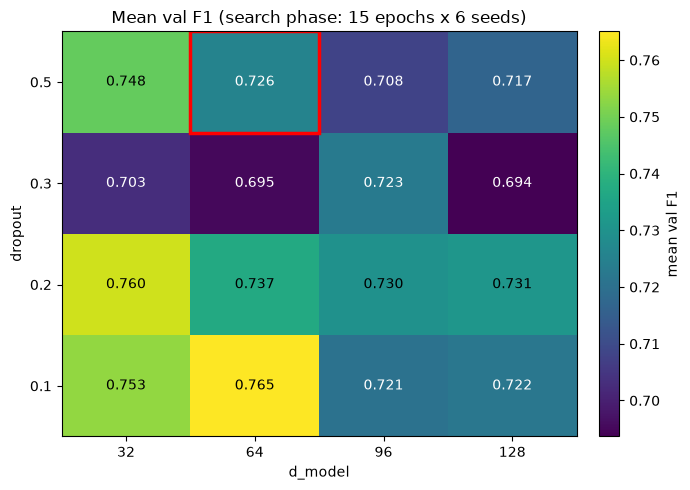

Red box = current baseline (d_model=64, dropout=0.5).


In [14]:
pivot_f1 = summary.pivot(index="dropout", columns="d_model", values="mean_val_f1")
pivot_f1 = pivot_f1.reindex(index=sorted(pivot_f1.index, reverse=True), columns=sorted(pivot_f1.columns))

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot_f1.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot_f1.columns))); ax.set_xticklabels(pivot_f1.columns)
ax.set_yticks(range(len(pivot_f1.index))); ax.set_yticklabels(pivot_f1.index)
ax.set_xlabel("d_model"); ax.set_ylabel("dropout")
ax.set_title(f"Mean val F1 (search phase: {SWEEP_EPOCHS} epochs x {len(SWEEP_SEEDS)} seeds)")
for i in range(pivot_f1.shape[0]):
    for j in range(pivot_f1.shape[1]):
        val = pivot_f1.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    color="white" if val < pivot_f1.values[~np.isnan(pivot_f1.values)].mean() else "black")
        if pivot_f1.columns[j] == BASELINE_D_MODEL and pivot_f1.index[i] == BASELINE_DROPOUT:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=2.5))
plt.colorbar(im, fraction=0.046, pad=0.04, label="mean val F1")
plt.tight_layout()
plt.savefig(SWEEP_OUT / "sweep_heatmap.png", dpi=150)
plt.show()
print("Red box = current baseline (d_model=64, dropout=0.5).")


In [15]:
best_row = summary.iloc[0]
baseline_row = summary[(summary["d_model"] == BASELINE_D_MODEL) & (summary["dropout"] == BASELINE_DROPOUT)]

print("=" * 70)
print("SEARCH-PHASE WINNER")
print("=" * 70)
print(f"  d_model={int(best_row['d_model'])}, dropout={best_row['dropout']:.1f} -> "
      f"mean val F1={best_row['mean_val_f1']:.4f} (std={best_row['std_val_f1']:.4f}), "
      f"mean val AUC={best_row['mean_val_auc']:.4f}")
if not baseline_row.empty:
    b = baseline_row.iloc[0]
    print(f"  baseline  d_model={BASELINE_D_MODEL}, dropout={BASELINE_DROPOUT} -> "
          f"mean val F1={b['mean_val_f1']:.4f} (std={b['std_val_f1']:.4f}), "
          f"mean val AUC={b['mean_val_auc']:.4f}")
    print(f"  delta (winner - baseline): F1 {best_row['mean_val_f1'] - b['mean_val_f1']:+.4f}, "
          f"AUC {best_row['mean_val_auc'] - b['mean_val_auc']:+.4f}")
print()
print("NOTE: these are reduced-budget search numbers (fewer epochs/seeds), useful only for")
print("ranking candidates. Run the confirmation cells below before reporting any final number.")

WINNER_D_MODEL = int(best_row["d_model"])
WINNER_DROPOUT = float(best_row["dropout"])


SEARCH-PHASE WINNER
  d_model=64, dropout=0.1 -> mean val F1=0.7651 (std=0.1163), mean val AUC=0.6343
  baseline  d_model=64, dropout=0.5 -> mean val F1=0.7256 (std=0.0205), mean val AUC=0.5880
  delta (winner - baseline): F1 +0.0395, AUC +0.0463

NOTE: these are reduced-budget search numbers (fewer epochs/seeds), useful only for
ranking candidates. Run the confirmation cells below before reporting any final number.


## Confirmation run

In [ ]:
def collect_group_probs_test_only(d_model, dropout, run_key, seeds, out_dir, loader_calib, loader_test):
    calib_probs, test_probs, calib_f1_per_seed, seeds_loaded = [], [], [], []
    calib_labels = test_labels = None
    for seed in seeds:
        state_path = out_dir / run_key / f"seed_{seed}" / "model_state.pt"
        if not state_path.exists():
            print(f"  [skip] no checkpoint for {run_key} seed={seed}")
            continue
        model = TrimodalFusionModel(
            rgb_backbone_name=RGB_BACKBONE_NAME, ir_backbone_name=IR_BACKBONE_NAME,
            d_model=d_model, dropout=dropout, cls_dropout=dropout, freeze_visual_backbone=True,
        ).to(cfg["device"])
        model.load_state_dict(torch.load(state_path, map_location=cfg["device"]))
        uncertainty_loss = UncertaintyWeightedLoss(n_tasks=3).to(cfg["device"])
        c_p, c_l, _, _ = collect_probs_labels(model, uncertainty_loss, loader_calib, cfg)
        t_p, t_l, _, _ = collect_probs_labels(model, uncertainty_loss, loader_test, cfg)
        thr, _ = calibrate_threshold(c_p[:, 1].tolist(), c_l)
        seed_f1 = f1_score(c_l, (c_p[:, 1] >= thr).astype(int).tolist(), average="binary", zero_division=0)
        calib_probs.append(c_p); test_probs.append(t_p)
        calib_f1_per_seed.append(seed_f1); seeds_loaded.append(seed)
        calib_labels, test_labels = c_l, t_l
    return {"calib_probs": calib_probs, "test_probs": test_probs, "calib_labels": calib_labels,
            "test_labels": test_labels, "calib_f1_per_seed": calib_f1_per_seed, "seeds_loaded": seeds_loaded}


def kfold_calibrate_and_evaluate(model_label, group):
    n = len(group["seeds_loaded"])
    if n == 0:
        print(f"  [{model_label}] no seeds loaded -- nothing to evaluate.")
        return None

    w = np.ones(n) / n
    avg_calib = np.tensordot(w, np.stack(group["calib_probs"]), axes=1)
    avg_test = np.tensordot(w, np.stack(group["test_probs"]), axes=1)

    calib_labels_arr = np.array(group["calib_labels"])
    min_class_count = min((calib_labels_arr == 0).sum(), (calib_labels_arr == 1).sum())
    K = max(2, min(6, int(min_class_count)))

    print(f"[{model_label}] calib (train+val) label counts: "
          f"not_spoiled={int((calib_labels_arr == 0).sum())}, spoiled={int((calib_labels_arr == 1).sum())} "
          f"-> K={K} folds")

    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=0)
    fold_thresholds, fold_f1s = [], []
    for fold_idx, (fold_train_idx, fold_heldout_idx) in enumerate(skf.split(avg_calib, calib_labels_arr)):
        fold_scores = avg_calib[fold_train_idx, 1].tolist()
        fold_labels = calib_labels_arr[fold_train_idx].tolist()
        thr, _ = calibrate_threshold(fold_scores, fold_labels)
        heldout_scores = avg_calib[fold_heldout_idx, 1]
        heldout_labels = calib_labels_arr[fold_heldout_idx]
        heldout_preds = (heldout_scores >= thr).astype(int)
        heldout_f1 = f1_score(heldout_labels, heldout_preds, average="binary", zero_division=0)
        fold_thresholds.append(thr); fold_f1s.append(heldout_f1)

    naive_threshold, _ = calibrate_threshold(avg_calib[:, 1].tolist(), group["calib_labels"])
    robust_threshold = float(np.median(fold_thresholds))
    threshold_spread = max(fold_thresholds) - min(fold_thresholds)

    test_preds_robust = (avg_test[:, 1] >= robust_threshold).astype(int).tolist()
    test_f1 = f1_score(group["test_labels"], test_preds_robust, average="binary", zero_division=0)
    try:
        test_auc = roc_auc_score(group["test_labels"], avg_test[:, 1])
    except ValueError:
        test_auc = float("nan")

    print(f"[{model_label}] TEST F1={test_f1:.4f}  TEST AUC={test_auc:.4f}  "
          f"(robust threshold={robust_threshold:.3f}, K={K}, spread={threshold_spread:.3f})")

    return {"n_seeds": n, "K": K, "robust_threshold": robust_threshold,
            "threshold_spread": threshold_spread, "test_f1": round(float(test_f1), 4),
            "test_auc": round(float(test_auc), 4)}


CONFIRM_EPOCHS = cfg["epochs"]          # full 30-epoch protocol
CONFIRM_SEEDS = list(range(10))         # full 10 seeds, matching 04_fusion_model.ipynb

candidates = {
    "baseline_d64_do0.5": (BASELINE_D_MODEL, BASELINE_DROPOUT),
    f"winner_d{WINNER_D_MODEL}_do{WINNER_DROPOUT}": (WINNER_D_MODEL, WINNER_DROPOUT),
}

confirm_test_results = {}
for run_key, (d_model, dropout) in candidates.items():
    print("=" * 90)
    print(f"CONFIRMATION RUN: {run_key}  (d_model={d_model}, dropout={dropout})")
    print("=" * 90)
    for i, seed in enumerate(CONFIRM_SEEDS, start=1):
        try:
            train_one_run_for_sweep(
                d_model, dropout, seed, CONFIRM_EPOCHS, run_key, SWEEP_OUT,
                train_loader, train_loader_calib, val_loader, verbose=True,
            )
        except Exception as e:
            print(f"  [FAILED] {run_key} seed={seed}: {type(e).__name__}: {e}")
            traceback.print_exc()

    group = collect_group_probs_test_only(d_model, dropout, run_key, CONFIRM_SEEDS, SWEEP_OUT,
                                           trainval_loader_calib, test_loader)
    confirm_test_results[run_key] = kfold_calibrate_and_evaluate(run_key, group)

print()
print("FINAL COMPARISON (full protocol, test set)")
for run_key, result in confirm_test_results.items():
    if result:
        print(f"  {run_key:30s} test_F1={result['test_f1']:.4f}  test_AUC={result['test_auc']:.4f}")
print()
print("Existing reported result (model_a_winner, d_model=64, dropout=0.5, from 04_fusion_model.ipynb):")
print("  test_F1=0.8000  test_AUC=0.7333")
print("(should match the 'baseline_d64_do0.5' row above, modulo training-run variance)")


CONFIRMATION RUN: baseline_d64_do0.5  (d_model=64, dropout=0.5)


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2921/1963621494.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


------------------------------------------------------------------------------------------
[d_model=64 dropout=0.5] seed 0 -- 30 epochs (unfreeze at 6/8/12), train (24 trajectories incl. augmentation), val (12 trajectories)
------------------------------------------------------------------------------------------
  seed 0 | epoch  1/30 | train_loss=62.0151 train_F1=0.636 | val_F1=0.625 val_AUC=0.306 thr=0.44  * | 6.2s
  seed 0 | epoch  2/30 | train_loss=54.3927 train_F1=0.621 | val_F1=0.533 val_AUC=0.389 thr=0.52 | 5.2s
  seed 0 | epoch  3/30 | train_loss=60.8310 train_F1=0.480 | val_F1=0.533 val_AUC=0.417 thr=0.56 | 6.3s
  seed 0 | epoch  4/30 | train_loss=59.1715 train_F1=0.480 | val_F1=0.308 val_AUC=0.250 thr=0.59 | 10.4s
  seed 0 | epoch  5/30 | train_loss=56.2887 train_F1=0.417 | val_F1=0.500 val_AUC=0.194 thr=0.61 | 8.9s
  seed 0 | epoch  6/30 | train_loss=60.3935 train_F1=0.688 | val_F1=0.364 val_AUC=0.472 thr=0.63 | 13.8s  [unfreeze last-1]
  seed 0 | epoch  7/30 | train_loss=5

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2921/1963621494.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


------------------------------------------------------------------------------------------
[d_model=64 dropout=0.5] seed 1 -- 30 epochs (unfreeze at 6/8/12), train (24 trajectories incl. augmentation), val (12 trajectories)
------------------------------------------------------------------------------------------
  seed 1 | epoch  1/30 | train_loss=63.6120 train_F1=0.828 | val_F1=0.706 val_AUC=0.694 thr=0.59  * | 7.8s
  seed 1 | epoch  2/30 | train_loss=57.6843 train_F1=0.571 | val_F1=0.706 val_AUC=0.694 thr=0.61 | 7.3s
  seed 1 | epoch  3/30 | train_loss=63.1294 train_F1=0.645 | val_F1=0.706 val_AUC=0.667 thr=0.63 | 5.7s
  seed 1 | epoch  4/30 | train_loss=63.7606 train_F1=0.462 | val_F1=0.706 val_AUC=0.583 thr=0.56 | 10.2s
  seed 1 | epoch  5/30 | train_loss=60.8016 train_F1=0.516 | val_F1=0.750 val_AUC=0.778 thr=0.61  * | 9.0s
  seed 1 | epoch  6/30 | train_loss=60.3195 train_F1=0.667 | val_F1=0.706 val_AUC=0.722 thr=0.61 | 10.6s  [unfreeze last-1]
  seed 1 | epoch  7/30 | train_los

...

------------------------------------------------------------------------------------------
[d_model=64 dropout=0.1] seed 8 -- 30 epochs (unfreeze at 6/8/12), train (24 trajectories incl. augmentation), val (12 trajectories)
------------------------------------------------------------------------------------------
  seed 8 | epoch  1/30 | train_loss=61.0727 train_F1=0.000 | val_F1=0.667 val_AUC=0.472 thr=0.10  * | 9.3s
  seed 8 | epoch  2/30 | train_loss=58.1983 train_F1=0.500 | val_F1=0.588 val_AUC=0.583 thr=0.46 | 5.5s
  seed 8 | epoch  3/30 | train_loss=60.8484 train_F1=0.703 | val_F1=0.571 val_AUC=0.528 thr=0.59 | 5.6s
  seed 8 | epoch  4/30 | train_loss=57.7335 train_F1=0.667 | val_F1=0.667 val_AUC=0.556 thr=0.10 | 7.6s
  seed 8 | epoch  5/30 | train_loss=58.4363 train_F1=0.800 | val_F1=0.706 val_AUC=0.583 thr=0.66  * | 8.6s
  seed 8 | epoch  6/30 | train_loss=58.0743 train_F1=0.545 | val_F1=0.625 val_AUC=0.611 thr=0.68 | 11.4s  [unfreeze last-1]
  seed 8 | epoch  7/30 | train_loss

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2921/1963621494.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


------------------------------------------------------------------------------------------
[d_model=64 dropout=0.1] seed 9 -- 30 epochs (unfreeze at 6/8/12), train (24 trajectories incl. augmentation), val (12 trajectories)
------------------------------------------------------------------------------------------
  seed 9 | epoch  1/30 | train_loss=61.2932 train_F1=0.000 | val_F1=0.667 val_AUC=0.694 thr=0.10  * | 9.7s
  seed 9 | epoch  2/30 | train_loss=58.9792 train_F1=0.133 | val_F1=0.706 val_AUC=0.556 thr=0.38  * | 6.1s
  seed 9 | epoch  3/30 | train_loss=58.5340 train_F1=0.545 | val_F1=0.615 val_AUC=0.444 thr=0.51 | 8.3s
  seed 9 | epoch  4/30 | train_loss=60.0006 train_F1=0.743 | val_F1=0.533 val_AUC=0.639 thr=0.58 | 8.6s
  seed 9 | epoch  5/30 | train_loss=58.3001 train_F1=0.722 | val_F1=0.625 val_AUC=0.528 thr=0.63 | 8.2s
  seed 9 | epoch  6/30 | train_loss=54.6429 train_F1=0.800 | val_F1=0.571 val_AUC=0.472 thr=0.70 | 13.5s  [unfreeze last-1]
  seed 9 | epoch  7/30 | train_loss

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2921/1963621494.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2921/1963621494.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2921/1963621494.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_2921/1963621494.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.n

[winner_d64_do0.1] calib (train+val) label counts: not_spoiled=12, spoiled=12 -> K=6 folds
[winner_d64_do0.1] TEST F1=0.6154  TEST AUC=0.3667  (robust threshold=0.610, K=6, spread=0.010)

FINAL COMPARISON (full protocol, test set)
  baseline_d64_do0.5             test_F1=0.6667  test_AUC=0.4333
  winner_d64_do0.1               test_F1=0.6154  test_AUC=0.3667

Existing reported result (model_a_winner, d_model=64, dropout=0.5, from 04_fusion_model.ipynb):
  test_F1=0.8000  test_AUC=0.7333
(should match the 'baseline_d64_do0.5' row above, modulo training-run variance)
